# B1 — SAR Flood Segmentation (U-Net / ResNet34)

**JalRakshak** · SIH26071 (MoES/IMD) · Team Blackbox

Sentinel-1 **SAR** (radar) imagery se paani ka mask nikalne wala model. Radar isliye ki
wo baadal ke aar-paar dekh leta hai — aur baadh ke waqt aasman hamesha bhara hota hai,
to optical satellite (Sentinel-2) us waqt bekaar ho jaata hai.

| | |
|---|---|
| **Dataset** | Sen1Floods11 (Cloud to Street / Google), CC-BY 4.0 — **hand-labeled subset** |
| **Chips** | 431 (train 252 / val 89 / test 90), 512x512, 10 m/px |
| **Input** | 2 bands — Sentinel-1 VV + VH, dB scale |
| **Labels** | `1` = water, `0` = not water, `-1` = **no data (ignore)** |
| **Model** | U-Net, ResNet34 encoder (ImageNet pretrained) |
| **Loss** | masked BCE + masked Dice |

### Do baatein jo is notebook ko imaandaar banati hain

1. **`-1` (no-data) pixels loss aur metrics DONO se hata diye gaye hain.**
   Ye train set ke **13.3%** pixels hain. Inhe "not water" maan lena sabse aam galti hai —
   usse IoU/accuracy jhoothi badh jaati hai. Yahan har jagah `valid = (label >= 0)` mask lagta hai.

2. **Sirf hand-labeled chips use kiye.** Sen1Floods11 mein 4,831 chips hain par baaki ke
   labels **algorithm** (Otsu threshold / JRC) se bane hain. Unpe train karke jo score aayega
   wo "humne algorithm ki nakal ki" batayega, "humne paani pehchanna seekha" nahi.
   446 hand-labeled chips mein insaan ne khud paani mark kiya hai. Kam data, par sach.

> Metrics jo bhi aayein, wahi likhe jaayenge. `ml/README.md` mein limitations bhi saaf hain.

In [1]:
%matplotlib inline
import os, random, json, time
from pathlib import Path

import numpy as np
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

# ---- Reproducibility -------------------------------------------------------
# KYUN: metrics deck mein jaayenge. Agar dobara chalane pe alag number aaye to
# koi bhi bharosa nahi karega. Seed fix karne se run-to-run wahi nateeja aata hai.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

HERE = Path.cwd()
DATA = HERE / "data"
MODELS = HERE / "models"; MODELS.mkdir(exist_ok=True)
OUT = HERE / "outputs"; OUT.mkdir(exist_ok=True)

# ---- Device ----------------------------------------------------------------
# MacBook M4 pe MPS (Metal) chalta hai — dedicated GPU nahi hai par Apple ka
# integrated GPU PyTorch se use ho jaata hai. Colab pe ye apne aap CUDA le lega.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)
print("torch:", torch.__version__, "| smp:", smp.__version__)

device: mps
torch: 2.8.0 | smp: 0.5.0


## 1. Config

SAR values **decibel** mein hote hain (typically -50 se +5 dB). Inhe seedha network mein
daalna theek nahi — isliye `[-50, 1]` pe clip karke `[0, 1]` mein scale karte hain.
Clip zaroori hai kyunki kabhi-kabhi bahut kam/zyada outlier aa jaate hain jo poori
normalization bigaad dete hain.

In [2]:
CFG = dict(
    epochs=40,
    batch_size=8,
    lr=1e-3,
    weight_decay=1e-4,
    encoder="resnet34",
    encoder_weights="imagenet",
    in_channels=2,          # VV + VH
    img_size=512,
    # SAR dB clipping range
    db_min=-50.0,
    db_max=1.0,
    threshold=0.5,          # sigmoid -> binary
    patience=10,            # early stopping (val IoU pe)
    seed=SEED,
)
IGNORE = -1                 # Sen1Floods11 ka no-data label
CFG

{'epochs': 40,
 'batch_size': 8,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'encoder': 'resnet34',
 'encoder_weights': 'imagenet',
 'in_channels': 2,
 'img_size': 512,
 'db_min': -50.0,
 'db_max': 1.0,
 'threshold': 0.5,
 'patience': 10,
 'seed': 42}

## 2. Dataset

`__getitem__` teen cheezein lautata hai: image, label, aur **valid mask**.
Wo valid mask hi is notebook ki reedh hai — loss aur metrics dono usse guzarte hain.

In [3]:
class Sen1Floods11(Dataset):
    """
    Sen1Floods11 hand-labeled chips.

    INPUT : split folder ('train' | 'valid' | 'test'), augment on/off
    OUTPUT: (image [2,H,W] float32 in [0,1], label [1,H,W] float32 {0,1},
             valid [1,H,W] float32 {0,1})

    KYUN valid mask alag lautate hain: label mein -1 (no data) hota hai. Usse
    0 ("not water") maan lena galat hai — wahan hume pata hi nahi ki kya tha.
    Alag mask se loss/metric un pixels ko poori tarah chhod dete hain.
    """

    def __init__(self, split: str, augment: bool = False):
        self.s1_dir = DATA / split / "S1"
        self.lb_dir = DATA / split / "Label"
        self.files = sorted(p.name for p in self.s1_dir.glob("*.tif"))
        self.augment = augment
        if not self.files:
            raise RuntimeError(f"{self.s1_dir} khaali hai — pehle download_data.py chalao")

    def __len__(self):
        return len(self.files)

    def _norm(self, arr: np.ndarray) -> np.ndarray:
        """dB -> [0,1]. Clip pehle, warna ek outlier poori image ko squash kar deta hai."""
        arr = np.nan_to_num(arr, nan=CFG["db_min"], posinf=CFG["db_max"], neginf=CFG["db_min"])
        arr = np.clip(arr, CFG["db_min"], CFG["db_max"])
        return (arr - CFG["db_min"]) / (CFG["db_max"] - CFG["db_min"])

    def __getitem__(self, i):
        name = self.files[i]
        with rasterio.open(self.s1_dir / name) as src:
            img = src.read().astype(np.float32)              # [2,H,W] VV,VH
        with rasterio.open(self.lb_dir / name.replace("S1Hand", "LabelHand")) as src:
            lab = src.read(1).astype(np.float32)             # [H,W] in {-1,0,1}

        img = self._norm(img)
        valid = (lab != IGNORE).astype(np.float32)
        lab = np.where(lab == 1, 1.0, 0.0).astype(np.float32)   # -1 aur 0 dono -> 0,
                                                                # par valid mask unhe alag rakhta hai

        if self.augment:
            # Sirf flips aur 90-degree rotations. KYUN: ye geometry badalte hain par
            # SAR ki backscatter value nahi. Brightness/contrast jitter yahan GALAT hoga —
            # dB value ka physical matlab hota hai, use badalna data ko jhootha kar dega.
            if random.random() < 0.5:
                img, lab, valid = img[:, :, ::-1], lab[:, ::-1], valid[:, ::-1]
            if random.random() < 0.5:
                img, lab, valid = img[:, ::-1, :], lab[::-1, :], valid[::-1, :]
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k, axes=(1, 2)); lab = np.rot90(lab, k); valid = np.rot90(valid, k)

        return (
            torch.from_numpy(np.ascontiguousarray(img)),
            torch.from_numpy(np.ascontiguousarray(lab)).unsqueeze(0),
            torch.from_numpy(np.ascontiguousarray(valid)).unsqueeze(0),
        )


train_ds = Sen1Floods11("train", augment=True)
val_ds   = Sen1Floods11("valid")
test_ds  = Sen1Floods11("test")
print(f"train {len(train_ds)} | valid {len(val_ds)} | test {len(test_ds)}")

train 252 | valid 89 | test 90


In [4]:
# num_workers=0 — macOS pe fork + rasterio kabhi-kabhi hang hota hai, aur dataset
# chhota hai to loading bottleneck bhi nahi.
train_dl = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False, num_workers=0)

# Sanity check — shapes aur class balance
x, y, v = next(iter(train_dl))
print("img", tuple(x.shape), x.dtype, f"[{x.min():.2f}, {x.max():.2f}]")
print("lab", tuple(y.shape), "water frac:", f"{y[v>0].mean():.4f}")
print("valid frac:", f"{v.mean():.4f}")

img (8, 2, 512, 512) torch.float32 [0.00, 1.00]
lab (8, 1, 512, 512) water frac: 0.1137
valid frac: 0.8704


### Data sanity — ek chip dekh lete hain

Blind train karna bura idea hai. Pehle aankh se dekh lo ki VV/VH aur label aapas mein
match karte hain — paani SAR mein **kaala** dikhta hai (smooth surface radar ko wapas
nahi bhejti, isliye low backscatter).

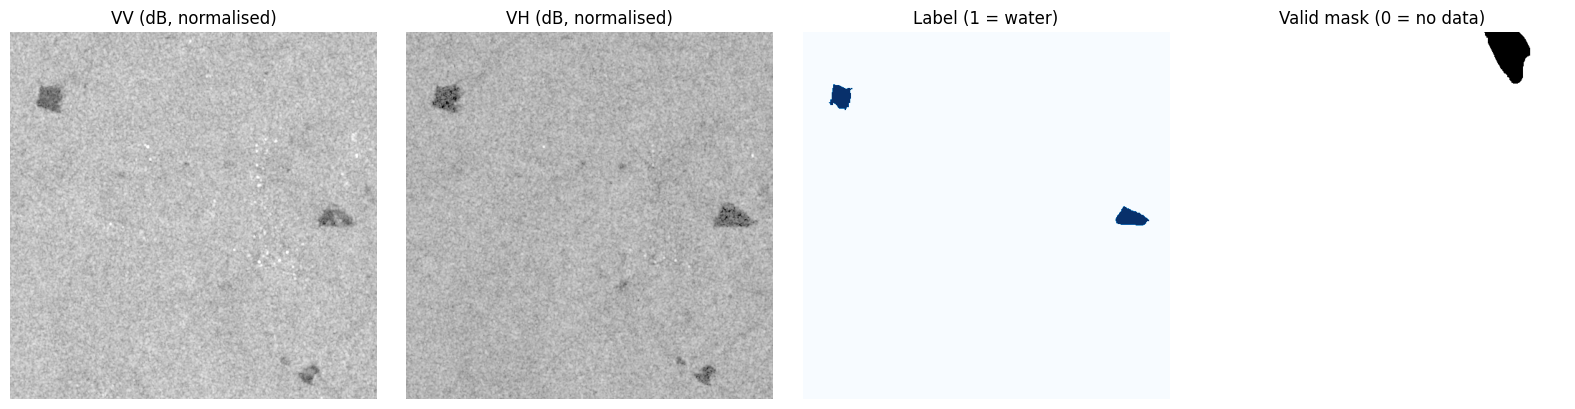

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
xi, yi, vi = train_ds[0]
axes[0].imshow(xi[0], cmap="gray"); axes[0].set_title("VV (dB, normalised)")
axes[1].imshow(xi[1], cmap="gray"); axes[1].set_title("VH (dB, normalised)")
axes[2].imshow(yi[0], cmap="Blues", vmin=0, vmax=1); axes[2].set_title("Label (1 = water)")
axes[3].imshow(vi[0], cmap="gray", vmin=0, vmax=1); axes[3].set_title("Valid mask (0 = no data)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.savefig(OUT / "sample_input.png", dpi=110, bbox_inches="tight")
plt.show()

## 3. Model, loss, metrics

**Loss = masked BCE + masked Dice.**
- BCE per-pixel sahi/galat dekhta hai
- Dice overlap dekhta hai — class imbalance (paani sirf ~8%) mein ye zaroori hai,
  kyunki akela BCE model ko "sab kuch not-water bol do" wale local minimum mein phasa deta hai

Dono ko `valid` mask se guzaara jaata hai.

In [6]:
model = smp.Unet(
    encoder_name=CFG["encoder"],
    encoder_weights=CFG["encoder_weights"],
    in_channels=CFG["in_channels"],   # smp pretrained 3-ch conv ko 2-ch mein adapt kar deta hai
    classes=1,
).to(DEVICE)

n_par = sum(p.numel() for p in model.parameters())
print(f"{CFG['encoder']} U-Net | {n_par/1e6:.1f}M params")

resnet34 U-Net | 24.4M params


In [7]:
def masked_bce_dice(logits, target, valid, eps=1e-7):
    """
    INPUT : logits [B,1,H,W], target {0,1}, valid {0,1}
    OUTPUT: scalar loss
    KYUN masked: -1 wale pixels pe hume ground truth pata hi nahi. Unpe loss dena
    matlab model ko shor sikhana.
    """
    bce = nn.functional.binary_cross_entropy_with_logits(logits, target, reduction="none")
    bce = (bce * valid).sum() / valid.sum().clamp(min=1)

    prob = torch.sigmoid(logits) * valid
    tgt = target * valid
    inter = (prob * tgt).sum(dim=(1, 2, 3))
    denom = prob.sum(dim=(1, 2, 3)) + tgt.sum(dim=(1, 2, 3))
    dice = 1 - ((2 * inter + eps) / (denom + eps))
    return bce + dice.mean()


@torch.no_grad()
def confusion(loader, model, thr):
    """
    Poore split ka pixel-level confusion matrix (sirf valid pixels).
    OUTPUT: tp, fp, fn, tn (ints)
    """
    model.eval()
    tp = fp = fn = tn = 0
    for x, y, v in loader:
        x, y, v = x.to(DEVICE), y.to(DEVICE), v.to(DEVICE)
        pred = (torch.sigmoid(model(x)) > thr).float()
        m = v > 0
        p, t = pred[m], y[m]
        tp += int(((p == 1) & (t == 1)).sum())
        fp += int(((p == 1) & (t == 0)).sum())
        fn += int(((p == 0) & (t == 1)).sum())
        tn += int(((p == 0) & (t == 0)).sum())
    return tp, fp, fn, tn


def scores(tp, fp, fn, tn, eps=1e-9):
    """Water class ke metrics. IoU = TP/(TP+FP+FN)."""
    return dict(
        iou=tp / (tp + fp + fn + eps),
        f1=2 * tp / (2 * tp + fp + fn + eps),
        precision=tp / (tp + fp + eps),
        recall=tp / (tp + fn + eps),
        accuracy=(tp + tn) / (tp + fp + fn + tn + eps),
    )

## 4. Training

Early stopping **validation IoU** pe hai, loss pe nahi — kyunki hume overlap chahiye,
aur imbalanced data mein loss girta rahe phir bhi IoU baith sakta hai.

In [8]:
opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["epochs"])

hist = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": [], "lr": []}
best_iou, best_epoch, patience = -1.0, -1, 0
CKPT = MODELS / "sar_unet.pth"
t_start = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    running = 0.0
    for x, y, v in train_dl:
        x, y, v = x.to(DEVICE), y.to(DEVICE), v.to(DEVICE)
        opt.zero_grad()
        loss = masked_bce_dice(model(x), y, v)
        loss.backward()
        opt.step()
        running += loss.item()
    train_loss = running / max(len(train_dl), 1)

    # --- validation ---
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y, v in val_dl:
            x, y, v = x.to(DEVICE), y.to(DEVICE), v.to(DEVICE)
            vl += masked_bce_dice(model(x), y, v).item()
    val_loss = vl / max(len(val_dl), 1)
    vs = scores(*confusion(val_dl, model, CFG["threshold"]))

    sched.step()
    hist["train_loss"].append(train_loss); hist["val_loss"].append(val_loss)
    hist["val_iou"].append(vs["iou"]); hist["val_f1"].append(vs["f1"])
    hist["lr"].append(opt.param_groups[0]["lr"])

    flag = ""
    if vs["iou"] > best_iou:
        best_iou, best_epoch, patience = vs["iou"], epoch, 0
        torch.save({"model": model.state_dict(), "cfg": CFG, "val_iou": best_iou, "epoch": epoch}, CKPT)
        flag = "  <- best, saved"
    else:
        patience += 1

    print(f"ep {epoch:>2}/{CFG['epochs']}  train {train_loss:.4f}  val {val_loss:.4f}  "
          f"IoU {vs['iou']:.4f}  F1 {vs['f1']:.4f}{flag}", flush=True)

    if patience >= CFG["patience"]:
        print(f"early stop — {CFG['patience']} epochs se val IoU nahi sudhra")
        break

print(f"\nbest val IoU {best_iou:.4f} @ epoch {best_epoch} | {(time.time()-t_start)/60:.1f} min")

ep  1/40  train 1.2905  val 1.0499  IoU 0.3837  F1 0.5546  <- best, saved


ep  2/40  train 1.0338  val 0.9670  IoU 0.5381  F1 0.6997  <- best, saved


ep  3/40  train 0.9489  val 0.8406  IoU 0.5410  F1 0.7022  <- best, saved


ep  4/40  train 0.8921  val 0.8691  IoU 0.5296  F1 0.6925


ep  5/40  train 0.8708  val 0.9456  IoU 0.5408  F1 0.7019


...

ep 37/40  train 0.7248  val 0.6414  IoU 0.6323  F1 0.7747


ep 38/40  train 0.7193  val 0.6409  IoU 0.6352  F1 0.7769


ep 39/40  train 0.7252  val 0.6461  IoU 0.6351  F1 0.7769


ep 40/40  train 0.7078  val 0.6500  IoU 0.6300  F1 0.7730


early stop — 10 epochs se val IoU nahi sudhra

best val IoU 0.6423 @ epoch 30 | 33.2 min


## 5. Training curves

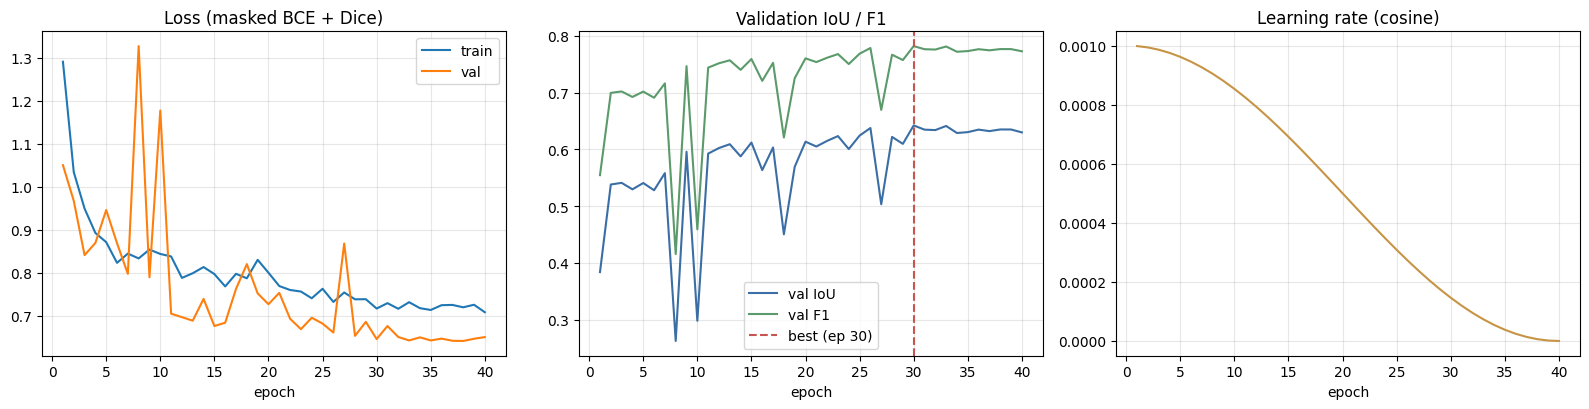

In [9]:
ep = range(1, len(hist["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ax[0].plot(ep, hist["train_loss"], label="train"); ax[0].plot(ep, hist["val_loss"], label="val")
ax[0].set_title("Loss (masked BCE + Dice)"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(ep, hist["val_iou"], color="#3b6ea5", label="val IoU")
ax[1].plot(ep, hist["val_f1"], color="#5b9a6b", label="val F1")
ax[1].axvline(best_epoch, ls="--", c="#c85450", label=f"best (ep {best_epoch})")
ax[1].set_title("Validation IoU / F1"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(ep, hist["lr"], color="#c79445"); ax[2].set_title("Learning rate (cosine)")
ax[2].set_xlabel("epoch"); ax[2].grid(alpha=.3)

plt.tight_layout(); plt.savefig(OUT / "training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Test evaluation

Test split ne training mein bhaag nahi liya aur model selection mein bhi nahi
(wo validation pe hua). Ye numbers hi asli hain — yehi README, model card aur deck mein jaayenge.

In [10]:
# Best checkpoint wapas load karo — aakhri epoch zaroori nahi ki best ho
ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
print(f"loaded best checkpoint (epoch {ck['epoch']}, val IoU {ck['val_iou']:.4f})")

tp, fp, fn, tn = confusion(test_dl, model, CFG["threshold"])
test = scores(tp, fp, fn, tn)

print("\n================ TEST SET (90 chips, held out) ================")
for k in ("iou", "f1", "precision", "recall", "accuracy"):
    print(f"  {k:>10}: {test[k]:.4f}")
print(f"\n  TP {tp:,}  FP {fp:,}  FN {fn:,}  TN {tn:,}")
print(f"  water pixels in test: {(tp+fn)/(tp+fp+fn+tn)*100:.2f}% of valid pixels")

loaded best checkpoint (epoch 30, val IoU 0.6423)



================ TEST SET (90 chips, held out) ================
         iou: 0.6489
          f1: 0.7871
   precision: 0.8038
      recall: 0.7710
    accuracy: 0.9478

  TP 1,978,522  FP 482,979  FN 587,579  TN 17,468,287
  water pixels in test: 12.51% of valid pixels


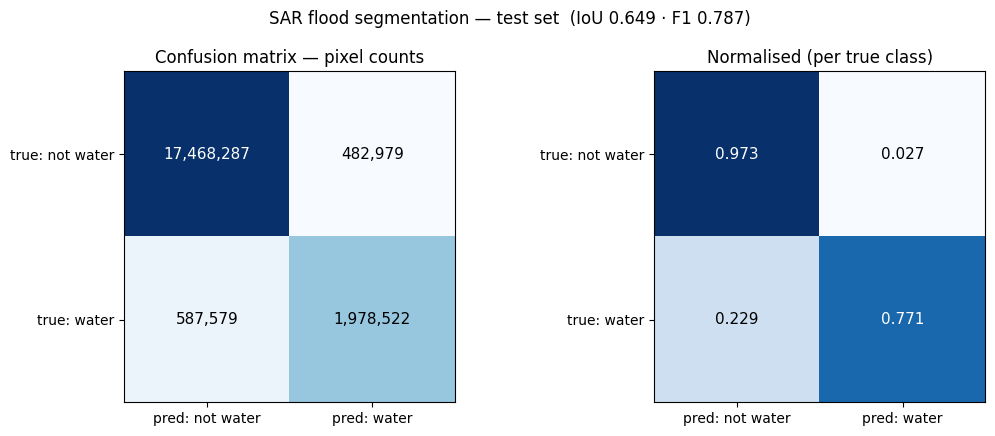

In [11]:
cm = np.array([[tn, fp], [fn, tp]], dtype=np.float64)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for i, (mat, title, fmt) in enumerate([
    (cm, "Confusion matrix — pixel counts", lambda v: f"{v:,.0f}"),
    (cm_norm, "Normalised (per true class)", lambda v: f"{v:.3f}"),
]):
    im = ax[i].imshow(mat if i else np.log10(mat + 1), cmap="Blues")
    ax[i].set_xticks([0, 1], ["pred: not water", "pred: water"])
    ax[i].set_yticks([0, 1], ["true: not water", "true: water"])
    ax[i].set_title(title)
    for r in range(2):
        for cc in range(2):
            v = mat[r, cc]
            ax[i].text(cc, r, fmt(v), ha="center", va="center",
                       color="white" if (v > mat.max() * 0.5) else "black", fontsize=11)
plt.suptitle(f"SAR flood segmentation — test set  (IoU {test['iou']:.3f} · F1 {test['f1']:.3f})")
plt.tight_layout(); plt.savefig(OUT / "confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

### Threshold sweep

0.5 default hai par optimal nahi hota. Ye dikhata hai ki precision/recall ka trade-off
kahan baithta hai — flood warning mein **recall** zyada important hai (paani chhoot jaana,
false alarm se bura hai).

  thr     IoU      F1    prec  recall
  0.2  0.6337  0.7758  0.7189  0.8425
  0.3  0.6452  0.7843  0.7554  0.8155
  0.4  0.6489  0.7871  0.7814  0.7928
  0.5  0.6489  0.7871  0.8038  0.7710
  0.6  0.6457  0.7847  0.8260  0.7474
  0.7  0.6369  0.7782  0.8511  0.7168
  0.8  0.6197  0.7652  0.8831  0.6750

best IoU 0.6489 @ threshold 0.5


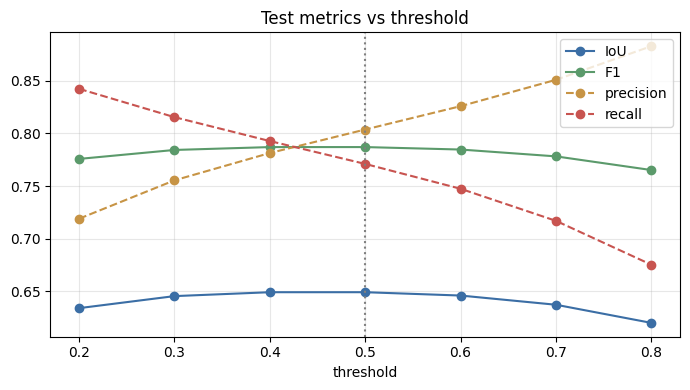

In [12]:
@torch.no_grad()
def sweep(loader, model, thrs):
    model.eval()
    probs, tgts = [], []
    for x, y, v in loader:
        x = x.to(DEVICE)
        p = torch.sigmoid(model(x)).cpu()
        m = v > 0
        probs.append(p[m].numpy()); tgts.append(y[m].numpy())
    probs = np.concatenate(probs); tgts = np.concatenate(tgts)
    rows = []
    for t in thrs:
        pr = probs > t
        tp = int(((pr == 1) & (tgts == 1)).sum()); fp = int(((pr == 1) & (tgts == 0)).sum())
        fn = int(((pr == 0) & (tgts == 1)).sum()); tn = int(((pr == 0) & (tgts == 0)).sum())
        rows.append((t, scores(tp, fp, fn, tn)))
    return rows

thrs = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
rows = sweep(test_dl, model, thrs)
print(f"{'thr':>5} {'IoU':>7} {'F1':>7} {'prec':>7} {'recall':>7}")
for t, s in rows:
    print(f"{t:>5.1f} {s['iou']:>7.4f} {s['f1']:>7.4f} {s['precision']:>7.4f} {s['recall']:>7.4f}")
best_t, best_s = max(rows, key=lambda r: r[1]["iou"])
print(f"\nbest IoU {best_s['iou']:.4f} @ threshold {best_t}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thrs, [s["iou"] for _, s in rows], "o-", label="IoU", color="#3b6ea5")
ax.plot(thrs, [s["f1"] for _, s in rows], "o-", label="F1", color="#5b9a6b")
ax.plot(thrs, [s["precision"] for _, s in rows], "o--", label="precision", color="#c79445")
ax.plot(thrs, [s["recall"] for _, s in rows], "o--", label="recall", color="#c85450")
ax.axvline(0.5, ls=":", c="grey"); ax.set_xlabel("threshold"); ax.grid(alpha=.3); ax.legend()
ax.set_title("Test metrics vs threshold")
plt.tight_layout(); plt.savefig(OUT / "threshold_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Qualitative — kuch test predictions

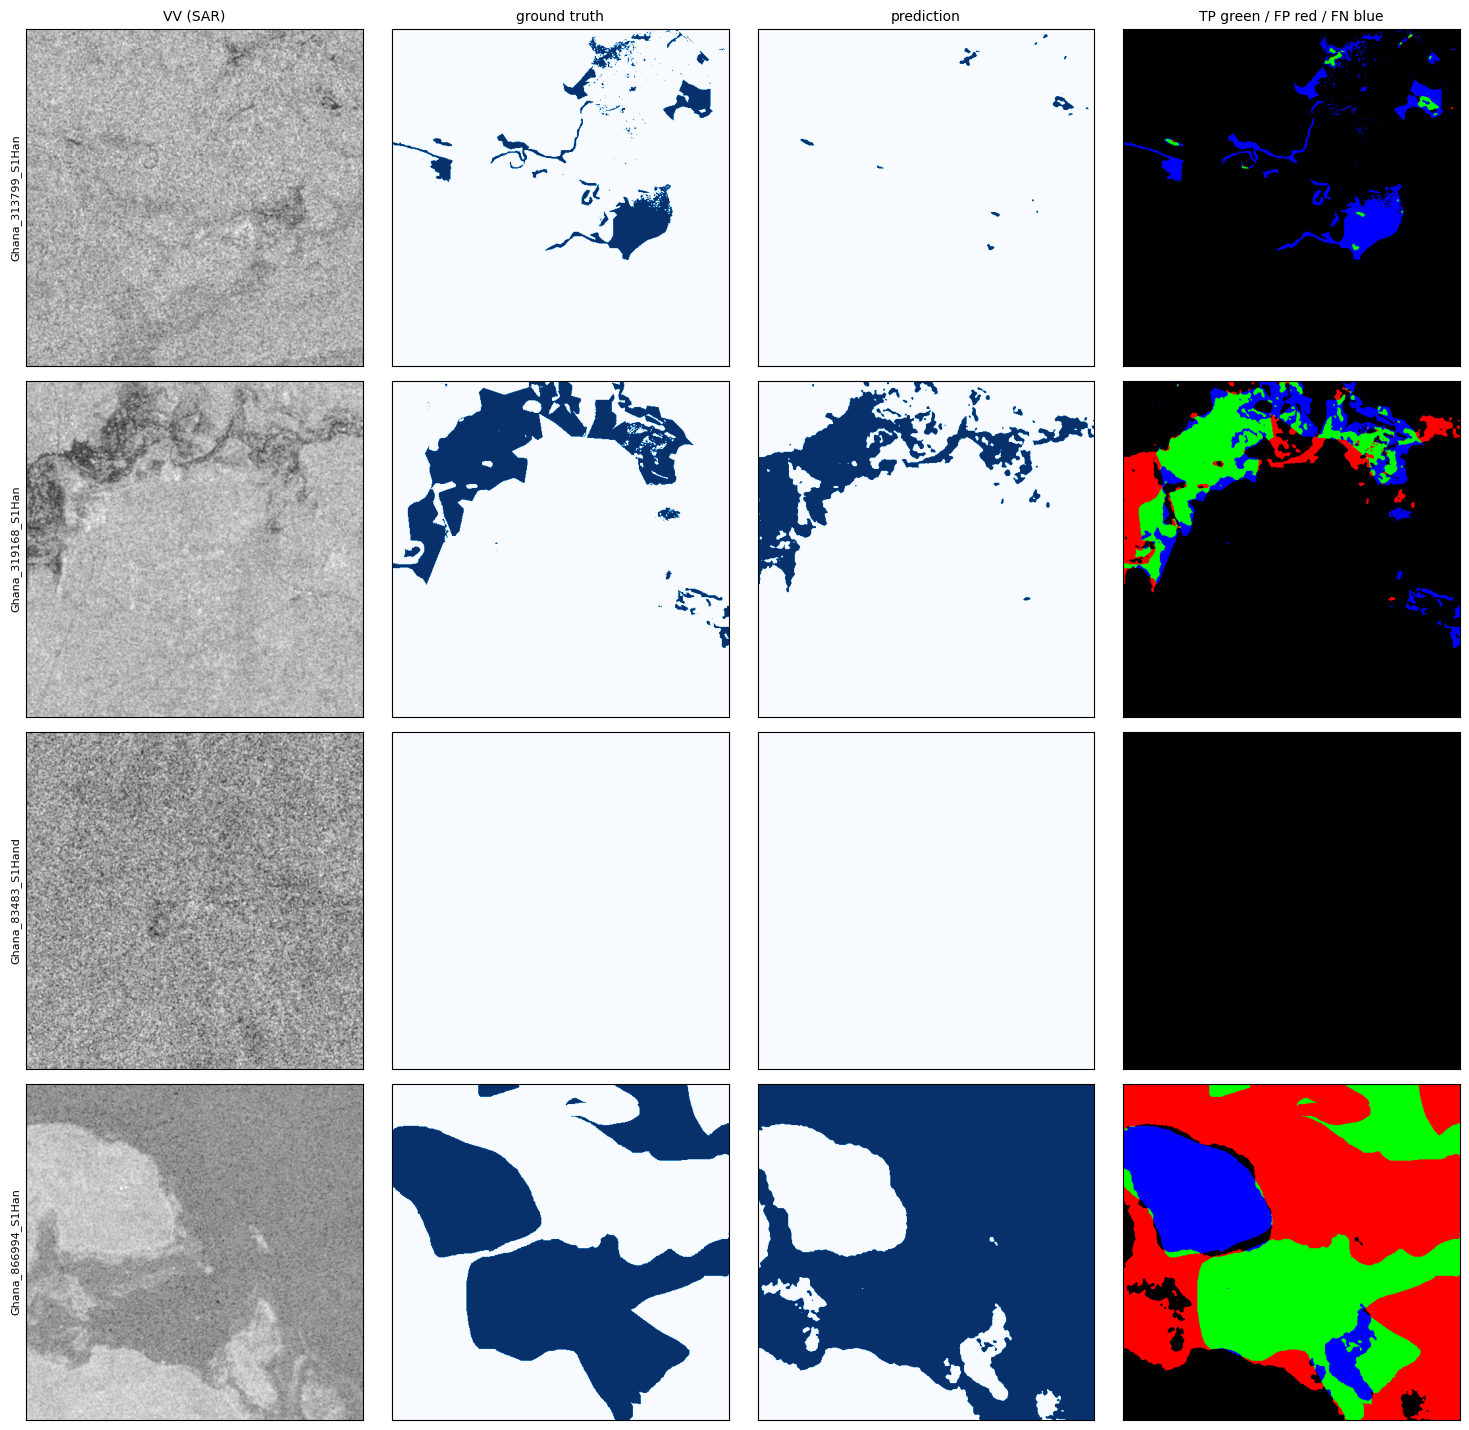

In [13]:
model.eval()
n = 4
fig, axes = plt.subplots(n, 4, figsize=(15, 3.6 * n))
picked = 0
with torch.no_grad():
    for idx in range(len(test_ds)):
        x, y, v = test_ds[idx]
        if y[v > 0].mean() < 0.05:   # aise chip chuno jisme thoda paani ho, warna sab kaala
            continue
        p = torch.sigmoid(model(x.unsqueeze(0).to(DEVICE)))[0, 0].cpu().numpy()
        pm = (p > CFG["threshold"]).astype(float)
        gt = y[0].numpy()
        tpm = np.zeros((*gt.shape, 3)); tpm[..., 0] = (pm == 1) & (gt == 0)   # FP red
        tpm[..., 1] = (pm == 1) & (gt == 1)                                    # TP green
        tpm[..., 2] = (pm == 0) & (gt == 1)                                    # FN blue
        r = picked
        axes[r, 0].imshow(x[0], cmap="gray");  axes[r, 0].set_ylabel(test_ds.files[idx][:18], fontsize=8)
        axes[r, 1].imshow(gt, cmap="Blues", vmin=0, vmax=1)
        axes[r, 2].imshow(pm, cmap="Blues", vmin=0, vmax=1)
        axes[r, 3].imshow(tpm)
        if r == 0:
            for a, t in zip(axes[r], ["VV (SAR)", "ground truth", "prediction", "TP green / FP red / FN blue"]):
                a.set_title(t, fontsize=10)
        for a in axes[r]: a.set_xticks([]); a.set_yticks([])
        picked += 1
        if picked == n: break
plt.tight_layout(); plt.savefig(OUT / "sample_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Save metrics (README / model card / dashboard isi file se padhte hain)

In [14]:
metrics = {
    "dataset": "Sen1Floods11 hand-labeled (CC-BY 4.0)",
    "splits": {"train": len(train_ds), "valid": len(val_ds), "test": len(test_ds)},
    "model": f"U-Net {CFG['encoder']} (ImageNet pretrained), in_ch={CFG['in_channels']}",
    "params_millions": round(n_par / 1e6, 2),
    "device": str(DEVICE),
    "epochs_run": len(hist["train_loss"]),
    "best_epoch": best_epoch,
    "best_val_iou": round(best_iou, 4),
    "threshold": CFG["threshold"],
    "test": {k: round(v, 4) for k, v in test.items()},
    "test_confusion": {"tp": tp, "fp": fp, "fn": fn, "tn": tn},
    "test_threshold_sweep": [
        {"threshold": t, **{k: round(v, 4) for k, v in s.items()}} for t, s in rows
    ],
    "best_threshold_by_iou": {"threshold": best_t, **{k: round(v, 4) for k, v in best_s.items()}},
    "notes": "Sirf valid pixels pe metrics (-1 no-data hataya gaya). Water = positive class.",
}
(OUT / "metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

{
  "dataset": "Sen1Floods11 hand-labeled (CC-BY 4.0)",
  "splits": {
    "train": 252,
    "valid": 89,
    "test": 90
  },
  "model": "U-Net resnet34 (ImageNet pretrained), in_ch=2",
  "params_millions": 24.43,
  "device": "mps",
  "epochs_run": 40,
  "best_epoch": 30,
  "best_val_iou": 0.6423,
  "threshold": 0.5,
  "test": {
    "iou": 0.6489,
    "f1": 0.7871,
    "precision": 0.8038,
    "recall": 0.771,
    "accuracy": 0.9478
  },
  "test_confusion": {
    "tp": 1978522,
    "fp": 482979,
    "fn": 587579,
    "tn": 17468287
  },
  "test_threshold_sweep": [
    {
      "threshold": 0.2,
      "iou": 0.6337,
      "f1": 0.7758,
      "precision": 0.7189,
      "recall": 0.8425,
      "accuracy": 0.9391
    },
    {
      "threshold": 0.3,
      "iou": 0.6452,
      "f1": 0.7843,
      "precision": 0.7554,
      "recall": 0.8155,
      "accuracy": 0.9439
    },
    {
      "threshold": 0.4,
      "iou": 0.6489,
      "f1": 0.7871,
      "precision": 0.7814,
      "recall": 0.7928,
